In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3140',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#2e3140',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'monospace',
})

ACCENT   = '#ff4655'   # VLR red
COLORS   = ['#ff4655','#00bcd4','#a8ff78','#ffb347','#c084fc','#60a5fa']
ROLE_COLORS = {
    'Duelist':    '#ff4655',
    'Initiator':  '#00bcd4',
    'Controller': '#a8ff78',
    'Sentinel':   '#ffb347',
}

print('Libraries loaded.')

Libraries loaded.


In [2]:
BASE_DIR_PATH = Path.cwd().parent
GOLD_PATH     = BASE_DIR_PATH / 'data' / 'gold'

spark = (
    SparkSession.builder
    .master('local[*]')
    .appName('gold-exploration')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('ERROR')

player_perf = spark.read.parquet(f"{GOLD_PATH}/gold_player_performance")
agent_meta  = spark.read.parquet(f"{GOLD_PATH}/gold_agent_meta")
map_stats   = spark.read.parquet(f"{GOLD_PATH}/gold_map_stats")

print(f"gold_player_performance : {player_perf.count():,} rows")
print(f"gold_agent_meta         : {agent_meta.count():,} rows")
print(f"gold_map_stats          : {map_stats.count():,} rows")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/05 18:24:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/03/05 18:24:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


gold_player_performance : 61,664 rows
gold_agent_meta         : 4,908 rows
gold_map_stats          : 1,952 rows


---
## 1. Top 20 Players by ACS
Minimum 100 rounds to filter out small samples.

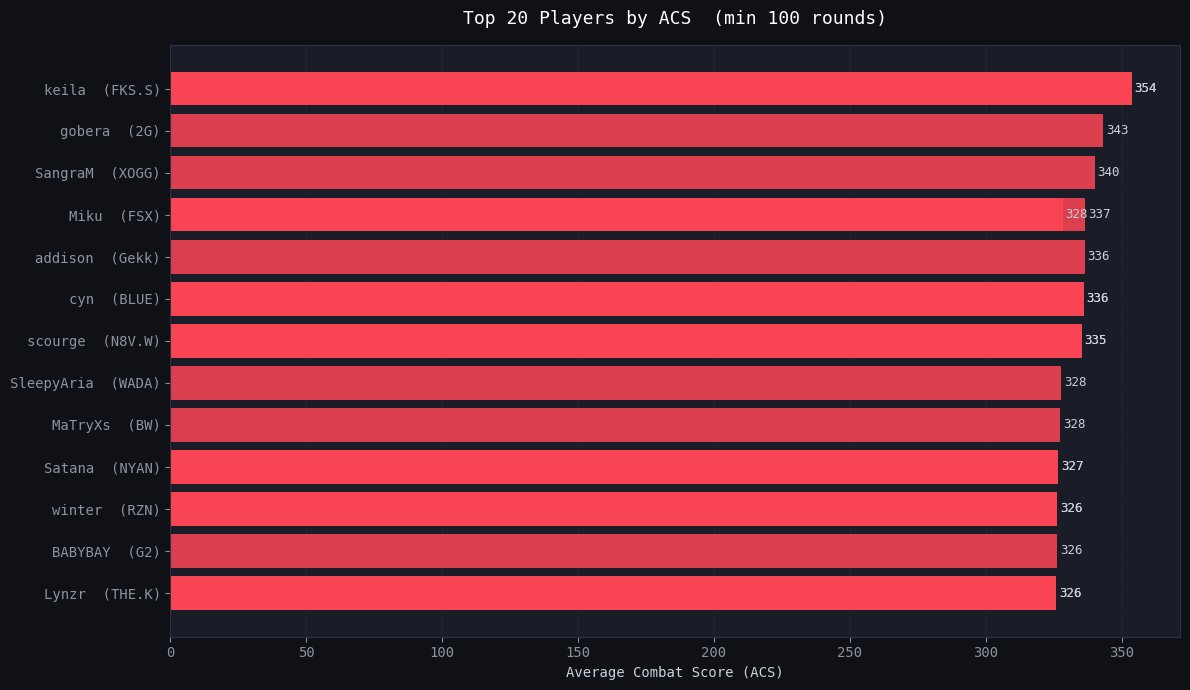

In [3]:
top_players_pd = (
    player_perf
    .filter(F.col('total_rounds') >= 100)
    .orderBy(F.col('avg_acs').desc())
    .select('player', 'org', 'region', 'avg_acs', 'avg_rating', 'avg_kd', 'avg_kast', 'total_rounds')
    .limit(20)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.barh(
    top_players_pd['player'] + '  (' + top_players_pd['org'].fillna('—') + ')',
    top_players_pd['avg_acs'],
    color=ACCENT, alpha=0.85, edgecolor='none'
)

# Value labels
for bar, val in zip(bars, top_players_pd['avg_acs']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', fontsize=9, color='#c9d1d9')

ax.invert_yaxis()
ax.set_xlabel('Average Combat Score (ACS)')
ax.set_title('Top 20 Players by ACS  (min 100 rounds)', fontsize=13, pad=15, color='white')
ax.grid(axis='x')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

---
## 2. ACS vs KD Scatter — player skill map
Top right = high ACS + high KD = elite fragger.
Size = total rounds played.

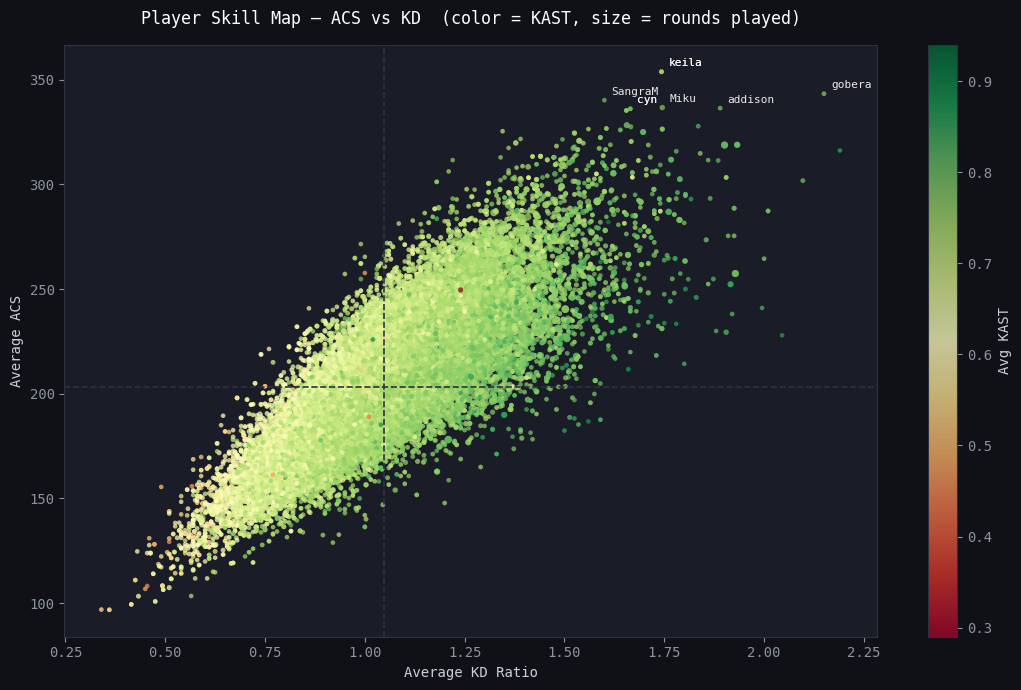

In [4]:
scatter_pd = (
    player_perf
    .filter(F.col('total_rounds') >= 100)
    .select('player', 'avg_acs', 'avg_kd', 'avg_kast', 'total_rounds', 'region')
    .toPandas()
)

fig, ax = plt.subplots(figsize=(11, 7))

sc = ax.scatter(
    scatter_pd['avg_kd'],
    scatter_pd['avg_acs'],
    s=scatter_pd['total_rounds'] / scatter_pd['total_rounds'].max() * 120 + 10,
    c=scatter_pd['avg_kast'],
    cmap='RdYlGn',
    alpha=0.75,
    edgecolors='none'
)

# Quadrant lines at medians
ax.axvline(scatter_pd['avg_kd'].median(),  color='#2e3140', linewidth=1.2, linestyle='--')
ax.axhline(scatter_pd['avg_acs'].median(), color='#2e3140', linewidth=1.2, linestyle='--')

# Label top 8 players
top8 = scatter_pd.nlargest(8, 'avg_acs')
for _, row in top8.iterrows():
    ax.annotate(row['player'], (row['avg_kd'], row['avg_acs']),
                xytext=(5, 4), textcoords='offset points',
                fontsize=8, color='white', alpha=0.9)

plt.colorbar(sc, ax=ax, label='Avg KAST')
ax.set_xlabel('Average KD Ratio')
ax.set_ylabel('Average ACS')
ax.set_title('Player Skill Map — ACS vs KD  (color = KAST, size = rounds played)',
             fontsize=12, pad=15, color='white')
plt.tight_layout()
plt.show()

---
## 3. Agent Pick Count — most picked agents in pro play

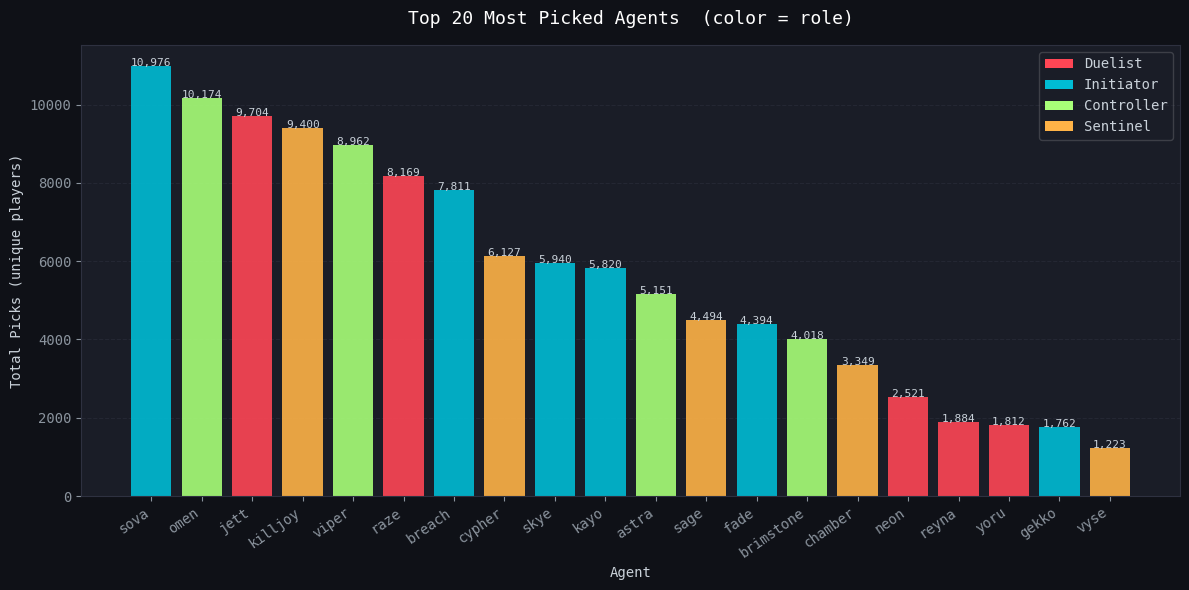

In [5]:
agent_picks_pd = (
    agent_meta
    .groupBy('agent', 'role')
    .agg(F.sum('pick_count').alias('total_picks'))
    .orderBy(F.col('total_picks').desc())
    .limit(20)
    .toPandas()
)

bar_colors = [ROLE_COLORS.get(r, '#888') for r in agent_picks_pd['role']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(agent_picks_pd['agent'], agent_picks_pd['total_picks'],
              color=bar_colors, edgecolor='none', alpha=0.9)

for bar, val in zip(bars, agent_picks_pd['total_picks']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{int(val):,}', ha='center', fontsize=8, color='#c9d1d9')

# Legend for roles
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=r) for r, c in ROLE_COLORS.items()]
ax.legend(handles=legend_elements, loc='upper right', framealpha=0.2)

ax.set_xlabel('Agent')
ax.set_ylabel('Total Picks (unique players)')
ax.set_title('Top 20 Most Picked Agents  (color = role)', fontsize=13, pad=15, color='white')
ax.grid(axis='y')
ax.set_axisbelow(True)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

---
## 4. Role Performance Comparison — ACS, KD, FK/FD by role

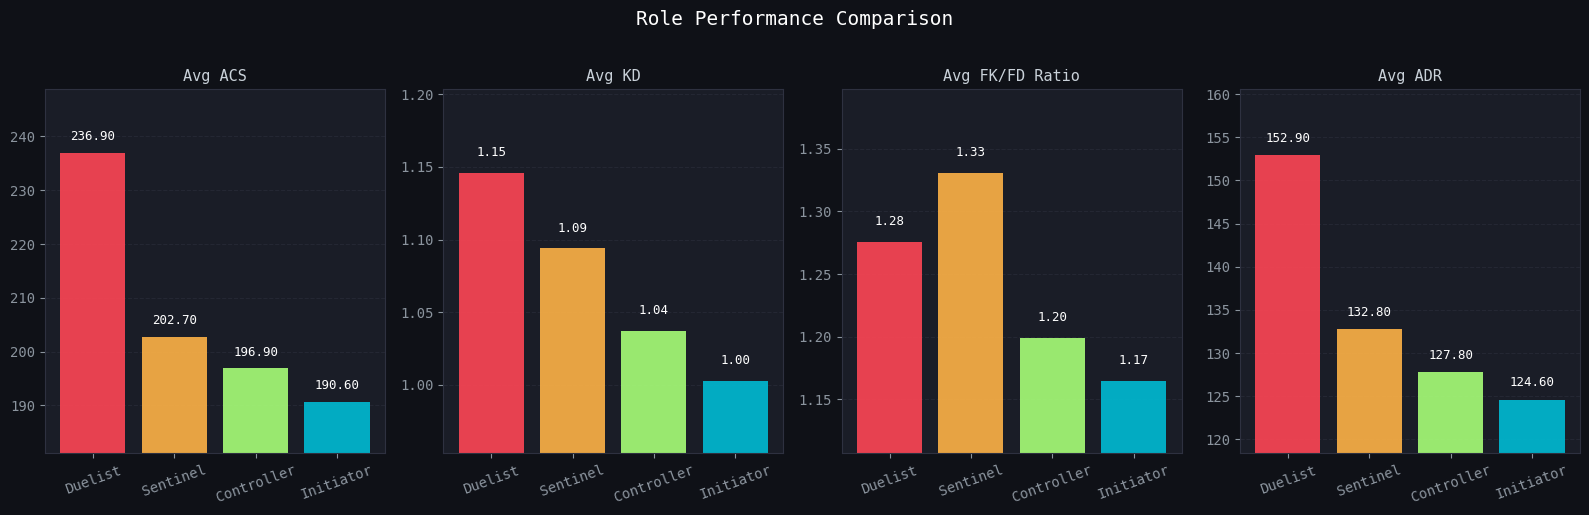

      role  avg_acs  avg_kd  avg_fk_fd  avg_adr  total_picks
   Duelist    236.9   1.146      1.276    152.9        26079
  Sentinel    202.7   1.094      1.331    132.8        25416
Controller    196.9   1.037      1.199    127.8        29931
 Initiator    190.6   1.003      1.165    124.6        37717


In [6]:
role_pd = (
    agent_meta
    .groupBy('role')
    .agg(
        F.round(F.avg('avg_acs'),          1).alias('avg_acs'),
        F.round(F.avg('avg_kd'),           3).alias('avg_kd'),
        F.round(F.avg('avg_fk_fd_ratio'),  3).alias('avg_fk_fd'),
        F.round(F.avg('avg_adr'),          1).alias('avg_adr'),
        F.sum('pick_count').alias('total_picks'),
    )
    .orderBy(F.col('avg_acs').desc())
    .toPandas()
)

metrics   = ['avg_acs', 'avg_kd', 'avg_fk_fd', 'avg_adr']
titles    = ['Avg ACS', 'Avg KD', 'Avg FK/FD Ratio', 'Avg ADR']
role_cols = [ROLE_COLORS.get(r, '#888') for r in role_pd['role']]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Role Performance Comparison', fontsize=14, color='white', y=1.02)

for ax, metric, title in zip(axes, metrics, titles):
    bars = ax.bar(role_pd['role'], role_pd[metric], color=role_cols,
                  edgecolor='none', alpha=0.9)
    for bar, val in zip(bars, role_pd[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01 * role_pd[metric].max(),
                f'{val:.2f}', ha='center', fontsize=9, color='white')
    ax.set_title(title, fontsize=11, color='#c9d1d9')
    ax.set_ylabel('')
    ax.grid(axis='y')
    ax.set_axisbelow(True)
    ax.tick_params(axis='x', rotation=20)
    # Narrow y range to amplify differences
    ymin = role_pd[metric].min() * 0.95
    ymax = role_pd[metric].max() * 1.05
    ax.set_ylim(ymin, ymax)

plt.tight_layout()
plt.show()
print(role_pd.to_string(index=False))

---
## 5. Map Stats — avg ACS and ADR by map

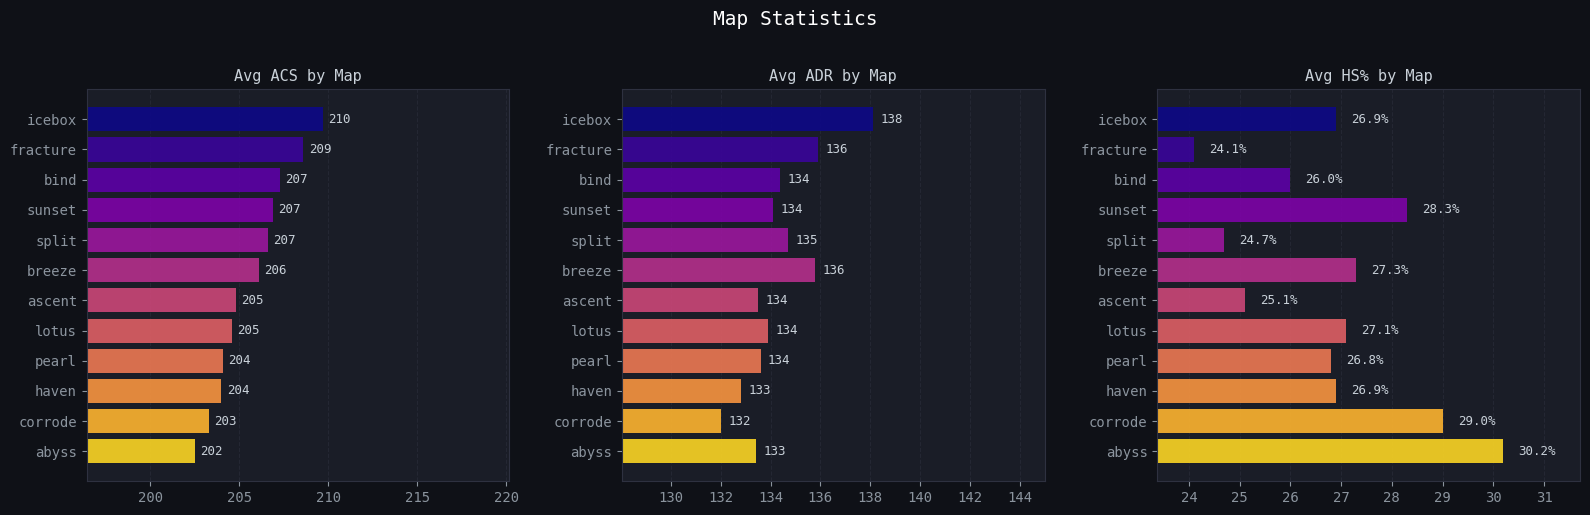

In [7]:
map_pd = (
    map_stats
    .groupBy('map')
    .agg(
        F.round(F.avg('avg_acs'), 1).alias('avg_acs'),
        F.round(F.avg('avg_adr'), 1).alias('avg_adr'),
        F.round(F.avg('avg_hs_pct') * 100, 1).alias('avg_hs_pct'),
        F.sum('unique_players').alias('total_players'),
    )
    .filter(F.col('map') != 'all')   # exclude 'all' aggregate rows if present
    .orderBy(F.col('avg_acs').desc())
    .toPandas()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Map Statistics', fontsize=14, color='white', y=1.02)

map_colors = plt.cm.plasma(
    [i / len(map_pd) for i in range(len(map_pd))]
)

for ax, col, title, fmt in zip(
    axes,
    ['avg_acs', 'avg_adr', 'avg_hs_pct'],
    ['Avg ACS by Map', 'Avg ADR by Map', 'Avg HS% by Map'],
    ['{:.0f}', '{:.0f}', '{:.1f}%']
):
    bars = ax.barh(map_pd['map'], map_pd[col], color=map_colors,
                   edgecolor='none', alpha=0.9)
    for bar, val in zip(bars, map_pd[col]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                fmt.format(val), va='center', fontsize=9, color='#c9d1d9')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11, color='#c9d1d9')
    ax.grid(axis='x')
    ax.set_axisbelow(True)
    xmin = map_pd[col].min() * 0.97
    ax.set_xlim(xmin, None)

plt.tight_layout()
plt.show()

---
## 6. Agent Performance Heatmap — ACS by agent and region

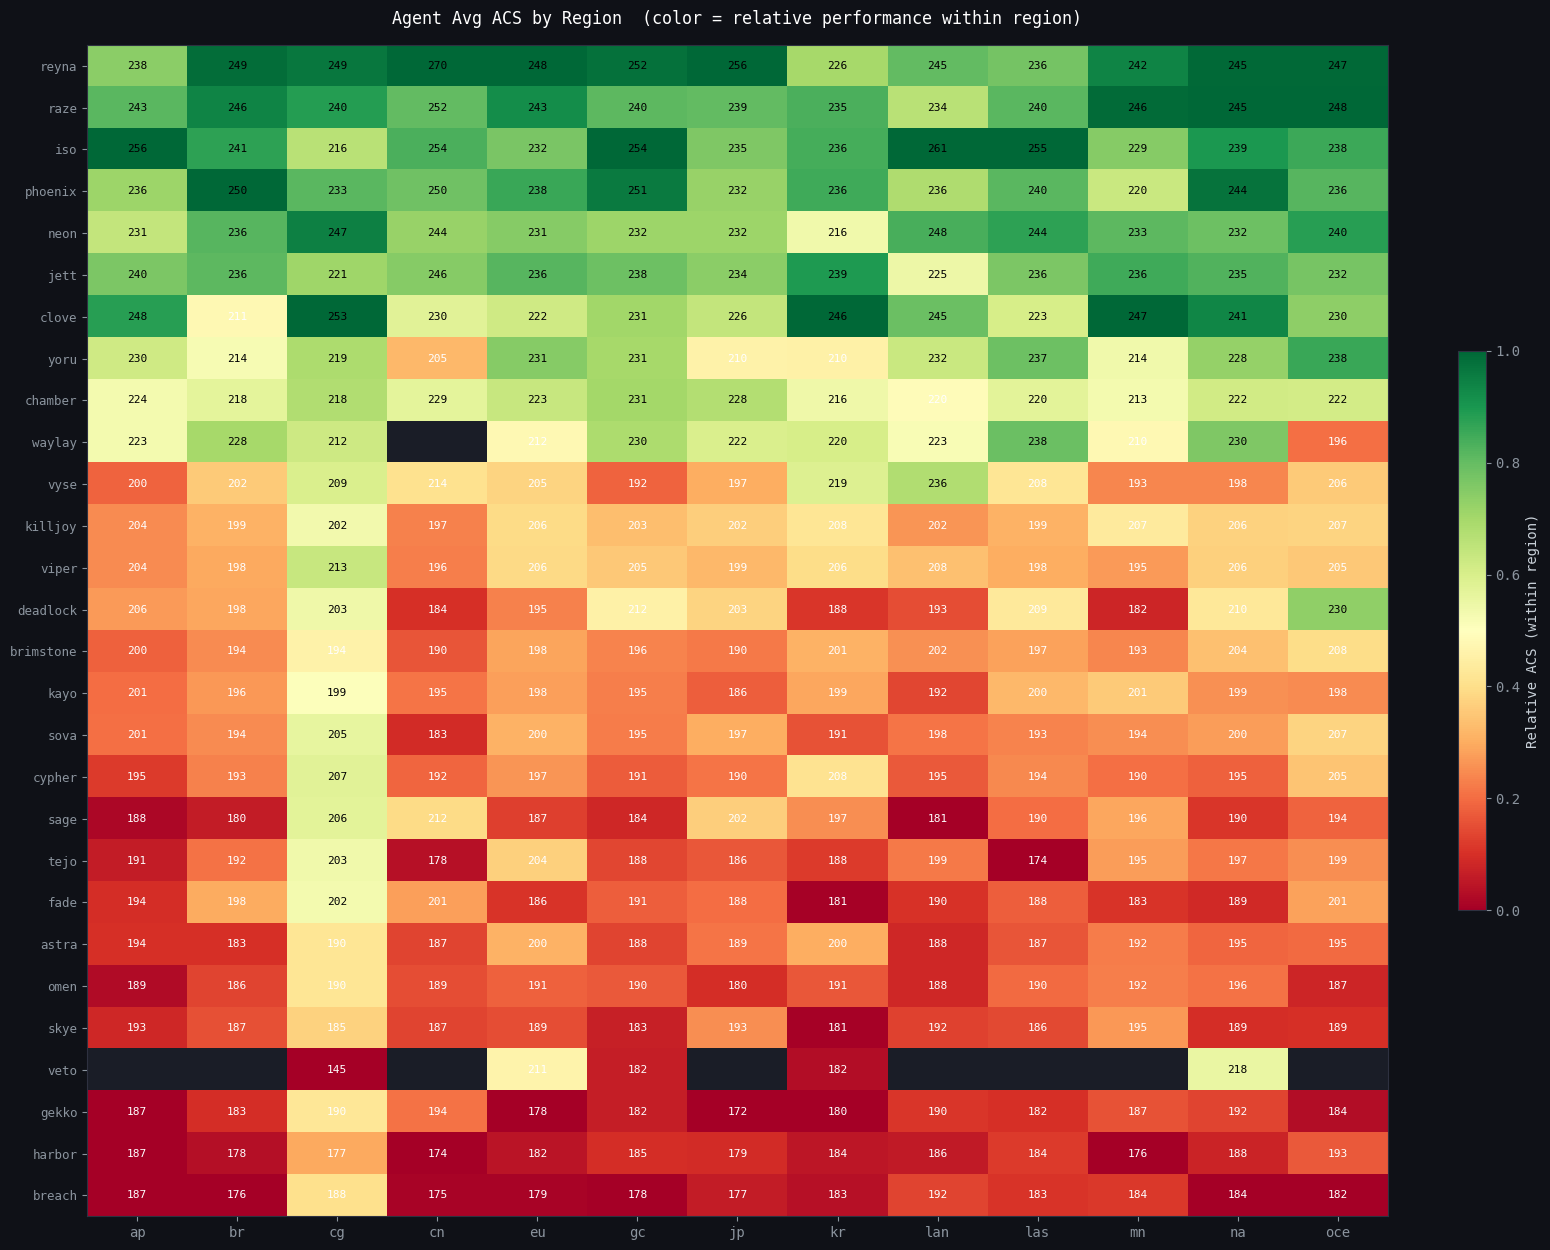

In [8]:
import numpy as np

heatmap_pd = (
    agent_meta
    .groupBy('agent', 'region')
    .agg(F.round(F.avg('avg_acs'), 1).alias('avg_acs'))
    .toPandas()
    .pivot(index='agent', columns='region', values='avg_acs')
)

# Sort agents by mean ACS descending
heatmap_pd = heatmap_pd.loc[heatmap_pd.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(max(8, len(heatmap_pd.columns) * 1.2), max(8, len(heatmap_pd) * 0.45)))

data = heatmap_pd.values
# Normalise per column so colors show relative performance within each region
col_min = np.nanmin(data, axis=0)
col_max = np.nanmax(data, axis=0)
norm_data = (data - col_min) / (col_max - col_min + 1e-9)

im = ax.imshow(norm_data, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Annotate cells with actual ACS values
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        val = data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                    fontsize=8, color='black' if norm_data[i, j] > 0.5 else 'white')

ax.set_xticks(range(len(heatmap_pd.columns)))
ax.set_xticklabels(heatmap_pd.columns, fontsize=10)
ax.set_yticks(range(len(heatmap_pd.index)))
ax.set_yticklabels(heatmap_pd.index, fontsize=9)
ax.set_title('Agent Avg ACS by Region  (color = relative performance within region)',
             fontsize=12, pad=15, color='white')

plt.colorbar(im, ax=ax, label='Relative ACS (within region)', fraction=0.02)
plt.tight_layout()
plt.show()

---
## 7. Entry Fragger Leaderboard — best FK/FD ratio players

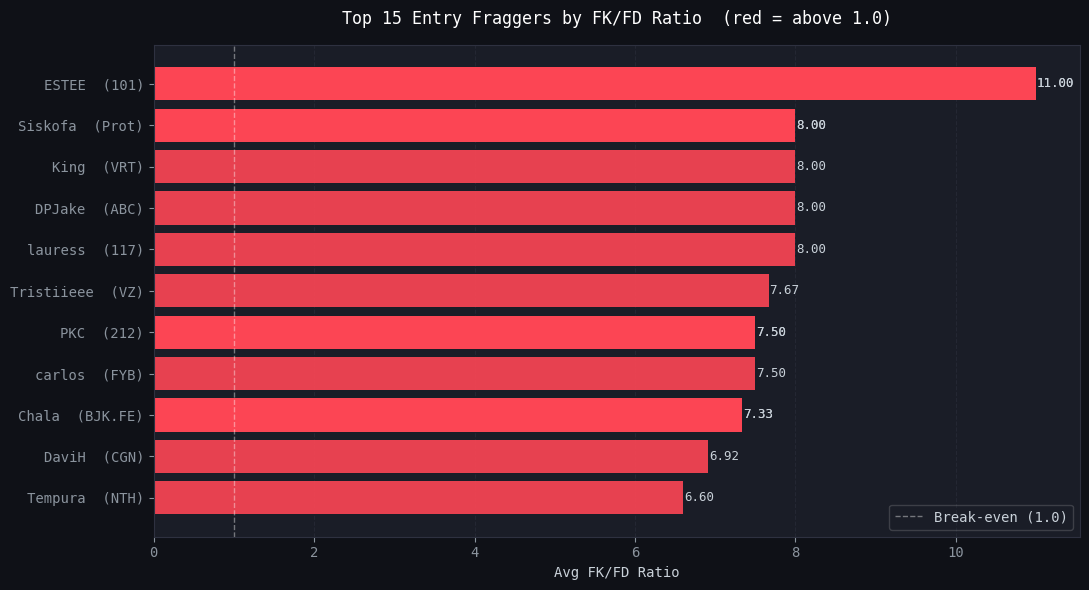

In [9]:
entry_pd = (
    player_perf
    .filter(
        (F.col('total_rounds') >= 100) &
        F.col('avg_fk_fd_ratio').isNotNull()
    )
    .orderBy(F.col('avg_fk_fd_ratio').desc())
    .select('player', 'org', 'region', 'avg_fk_fd_ratio',
            'total_first_kills', 'total_first_deaths', 'total_rounds')
    .limit(15)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(11, 6))

bar_colors = [ACCENT if v >= 1.0 else '#60a5fa' for v in entry_pd['avg_fk_fd_ratio']]
bars = ax.barh(
    entry_pd['player'] + '  (' + entry_pd['org'].fillna('—') + ')',
    entry_pd['avg_fk_fd_ratio'],
    color=bar_colors, edgecolor='none', alpha=0.9
)

for bar, val in zip(bars, entry_pd['avg_fk_fd_ratio']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=9, color='#c9d1d9')

ax.axvline(1.0, color='white', linewidth=1, linestyle='--', alpha=0.4, label='Break-even (1.0)')
ax.invert_yaxis()
ax.set_xlabel('Avg FK/FD Ratio')
ax.set_title('Top 15 Entry Fraggers by FK/FD Ratio  (red = above 1.0)',
             fontsize=12, pad=15, color='white')
ax.legend(framealpha=0.2)
ax.grid(axis='x')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [10]:
spark.stop()
print('Done.')

Done.
